# Dataset : 

Link : https://www.kaggle.com/competitions/boston-housing/data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# !pip install pandas matplotlib seaborn

In [3]:
train_path = "boston-housing/train.csv"
test_path = "boston-housing/test.csv"

In [4]:
train_df = pd.read_csv(train_path)

In [5]:
train_df.columns.to_list()

['ID',
 'crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'black',
 'lstat',
 'medv']

In [6]:
FEATURE_COLUMNS = [
    'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 
    'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat'
]

# Part 1

In [7]:
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [8]:
# itetaion-1 : simple --> model ->evaluation(model, test) --> 98%

In [9]:
train_df.shape

(333, 15)

In [10]:
def basic_summary(df):
    print(f"Missing values : {df.isnull().sum()}")
    print(f"Data DTypes : {df.dtypes}")
    print(f"Dataframe stats : {df.describe().T}")

In [11]:
basic_summary(train_df)

Missing values : ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64
Data DTypes : ID           int64
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object
Dataframe stats :          count        mean         std        min        25%        50%  \
ID       333.0  250.951952  147.859438    1.00000  123.00000  244.00000   
crim     333.0    3.360341    7.352272    0.00632    0.07896    0.26169   
zn       333.0   10.689189   22.674762    0.00000    0.00000    0.00000   
indus    333.0   11.293483    6.998123    0.74000    5.13000    9.90000   
chas     333.0    0.060060    0.237956    0.00000    0.00000    0.000

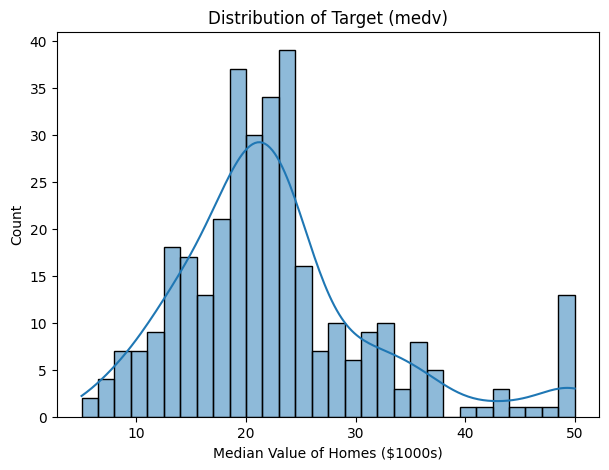

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(train_df["medv"], kde=True, bins=30)
plt.title("Distribution of Target (medv)")
plt.xlabel("Median Value of Homes ($1000s)")
plt.ylabel("Count")
plt.show()

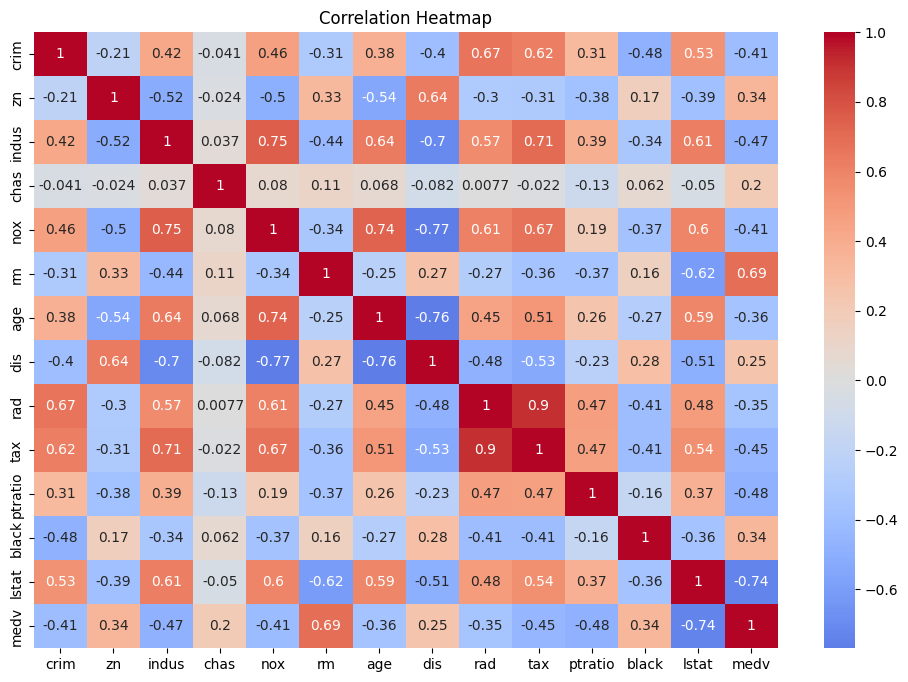

In [13]:
plt.figure(figsize=(12,8))
corr = train_df.drop(columns=["ID"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

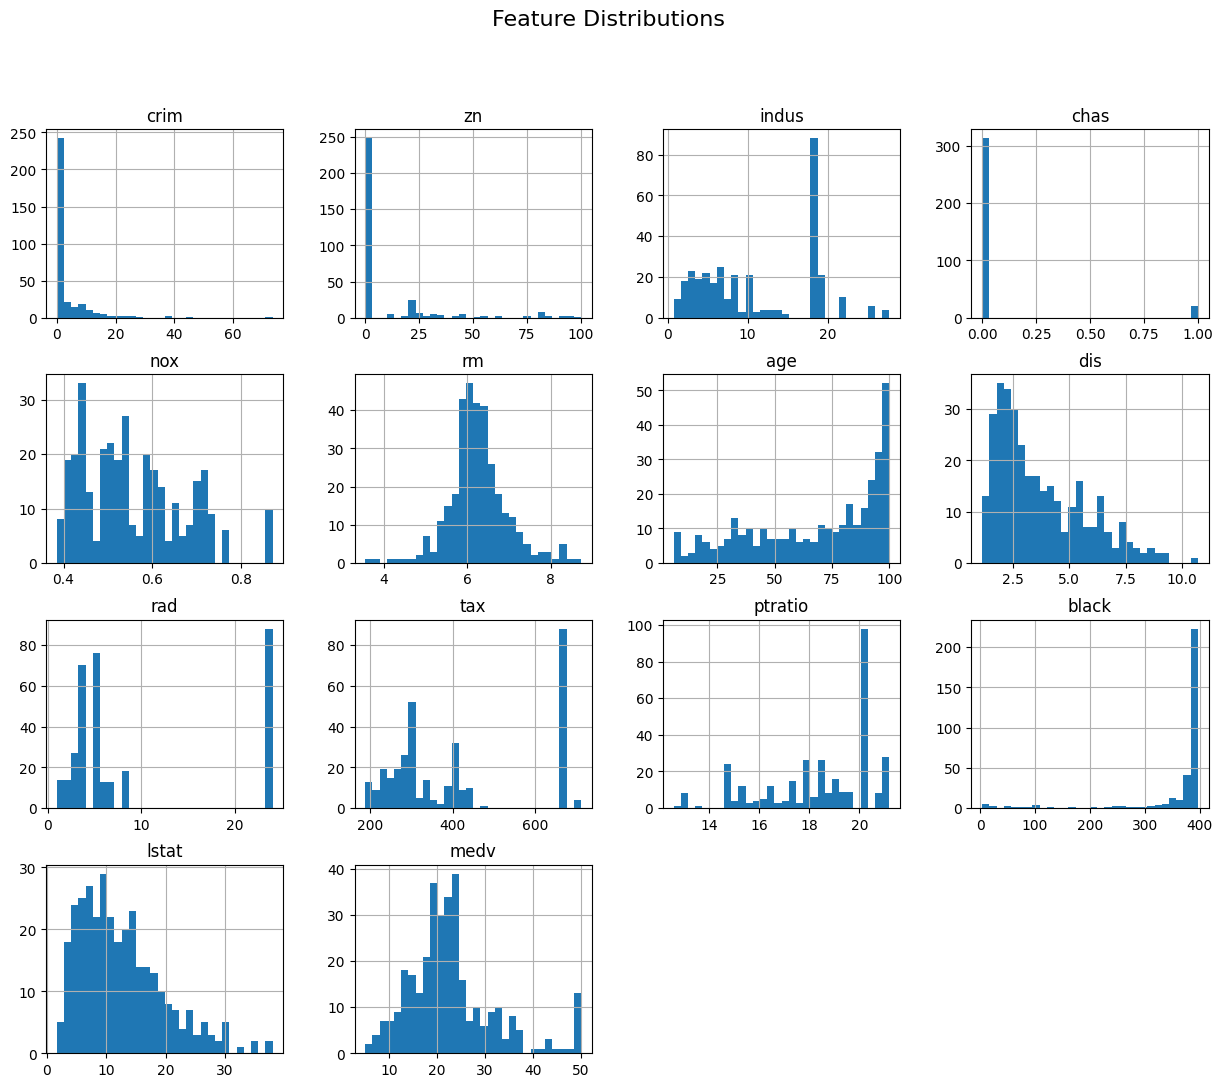

In [14]:
train_df.drop(columns=["ID"]).hist(figsize=(15,12), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

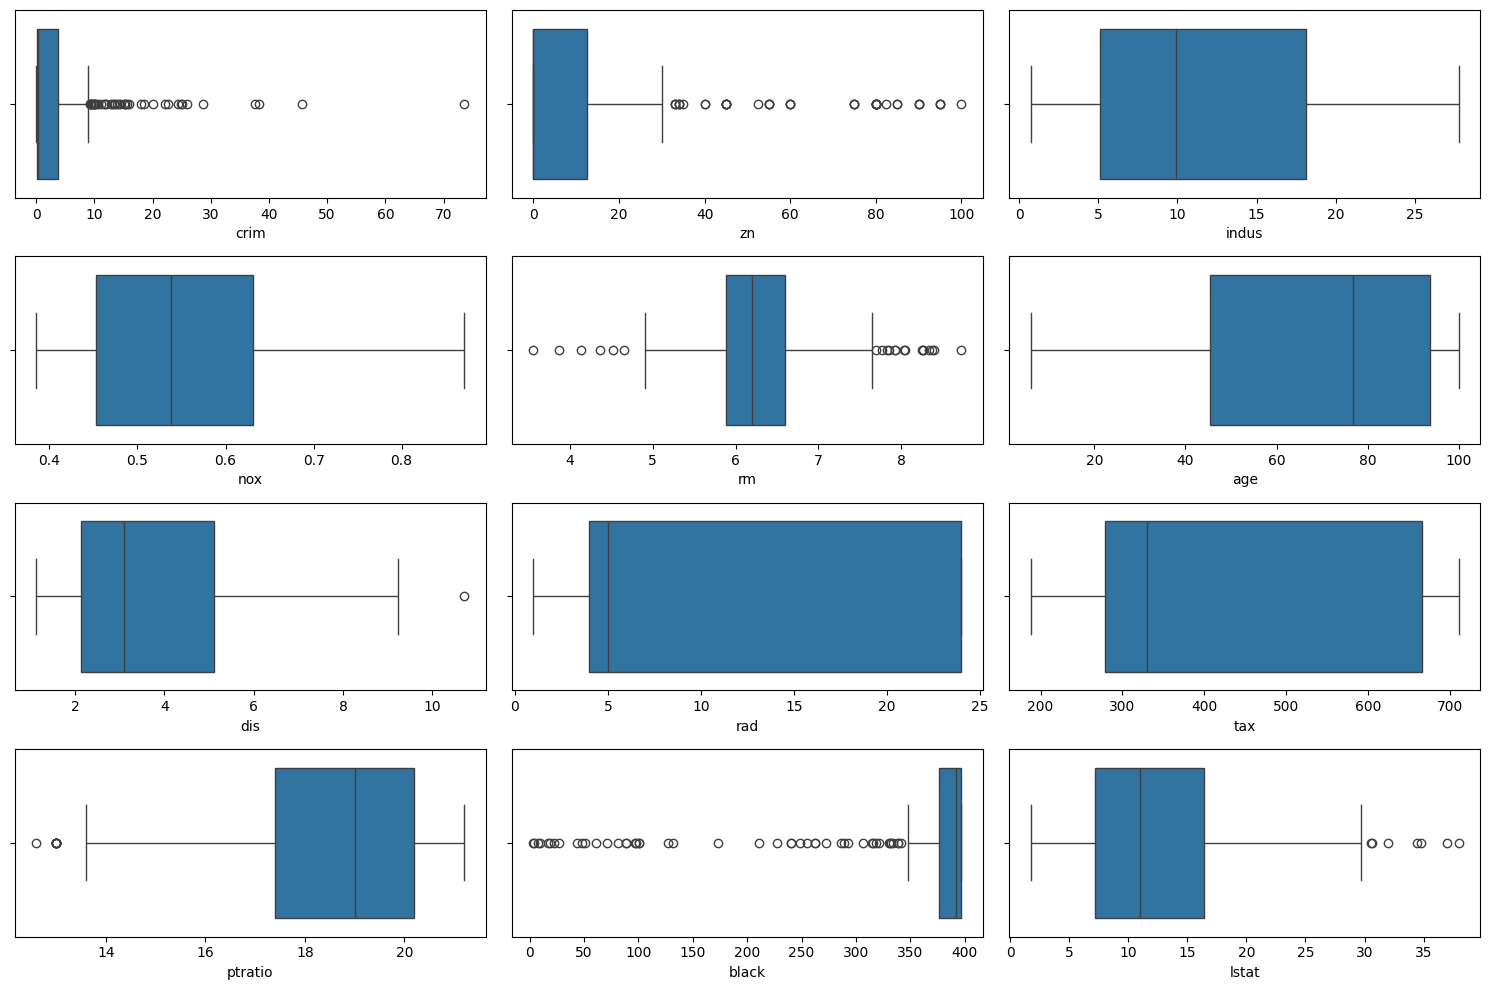

In [15]:
numeric_cols = train_df.drop(columns=["ID", "chas", "medv"]).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=train_df[col])
    # plt.title(col)
plt.tight_layout()
plt.show()

# Part 2

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [17]:
# !pip install scikit-learn

In [18]:
X_train_full = train_df.drop(columns=["ID", "medv"])
y_train_full = train_df['medv']

In [19]:
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_full, y_train_full,  test_size=0.3, random_state=20)

In [20]:
print(X_train_full.shape[0])
print(X_train_split.shape[0])
print(X_test_split.shape[0])

333
233
100


In [21]:
100/333

0.3003003003003003

In [22]:
numeric_features = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']
categorical_features = ['chas', 'rad']

In [ ]:
numeric_transformer = StandardScaler()
# categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop=None)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough' # keep the remaining column as is, no transformation
)

In [25]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [26]:
X_train_processed = preprocessor.fit_transform(X_train_split)
X_test_processed = preprocessor.transform(X_test_split)

In [27]:
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (233, 20)
X_test_processed shape: (100, 20)


# Part 3

In [28]:
# TRAIN MODEL USING SGDREGRESSOR
sgd_reg = SGDRegressor(
    max_iter=1000,
    eta0=0.01, # Learning rate,
    random_state=5
)

In [29]:
sgd_reg.fit(X_train_processed, y_train_split)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",5
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


In [30]:
sgd_reg.coef_

array([-0.38380188,  0.8683008 , -0.01083271, -1.22581814,  2.90165376,
        0.05159882, -2.91223521, -1.40392135, -1.88084274,  1.22698572,
       -4.64566683,  3.25025438,  0.40018433,  3.49131974,  1.63224267,
        1.7337928 , -0.21729018,  3.04064211,  3.2847097 ,  6.0140854 ])

In [ ]:
sgd_reg.intercept_

array([19.67239363])

In [32]:
# OLS
linear_reg_ols = LinearRegression()

In [33]:
linear_reg_ols.fit(X_train_processed, y_train_split)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-0.42, 1.09, 0.28,..., 6.1 , 4.74, 6.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[37.44,16.65,15.55,..., 2.74, 2. , 0.87]"


# Test Model

In [34]:
y_test_pred = sgd_reg.predict(X_test_processed)
y_train_pred = sgd_reg.predict(X_train_processed)

In [35]:
# Evaluation
from sklearn.metrics import mean_squared_error

In [36]:
mse_train = mean_squared_error(y_train_split, y_train_pred)
mse_test = mean_squared_error(y_test_split, y_test_pred)

print(f"MSE (TRAIN) (SGD) : {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")

MSE (TRAIN) (SGD) : 21.26978414072599
MSE (TEST) (SGD): 23.273431709637862


In [37]:
def plot_actual_vs_predicted_lines(y_actual, y_predicted):
    plt.figure(figsize=(14, 7))

    if isinstance(y_actual, pd.Series):
        y_actual = y_actual.values
    
    plt.plot(y_actual, label='Actual Values', color='#1f77b4', linewidth=2)

    plt.plot(y_predicted, label='Predicted Values', color='#ff7f0e', linewidth=2, linestyle='--')
    
    plt.title('Actual vs. Predicted Values Over Index (Trend Comparison)')
    plt.xlabel('Data Index')
    plt.ylabel('Median Home Value')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


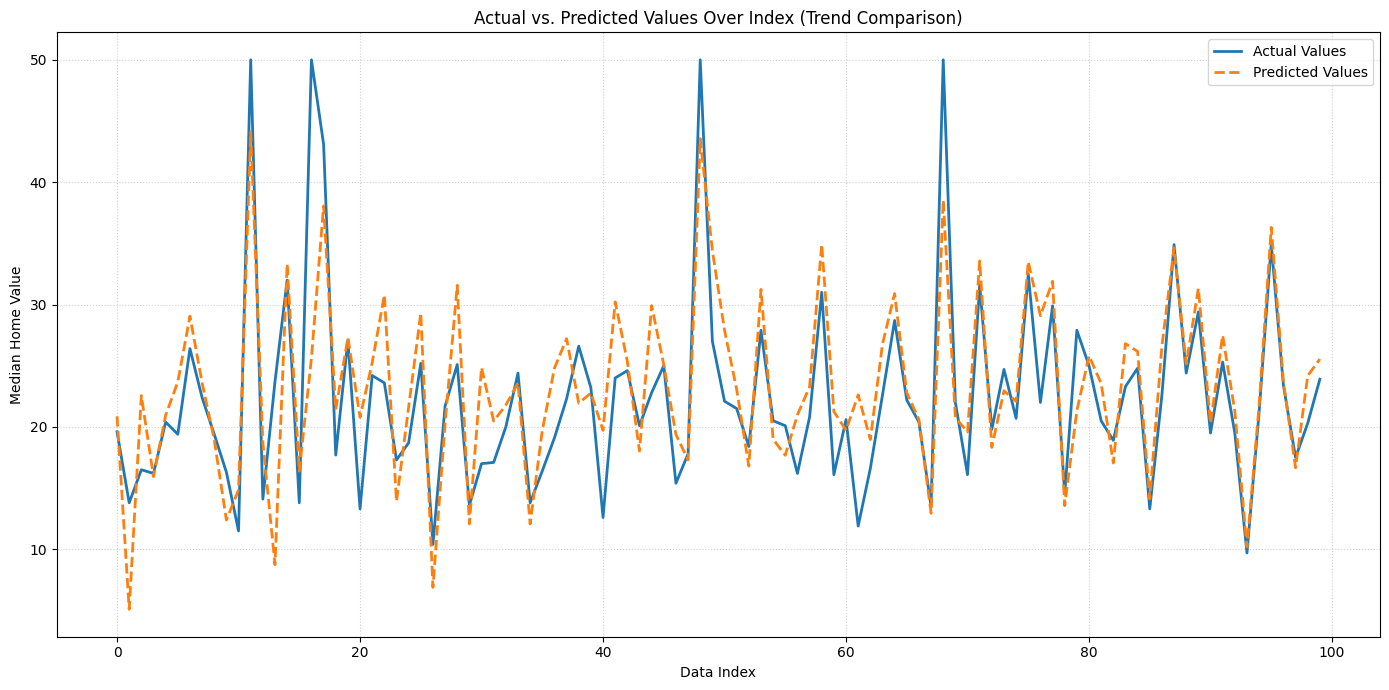

In [38]:
plot_actual_vs_predicted_lines(y_test_split, y_test_pred)

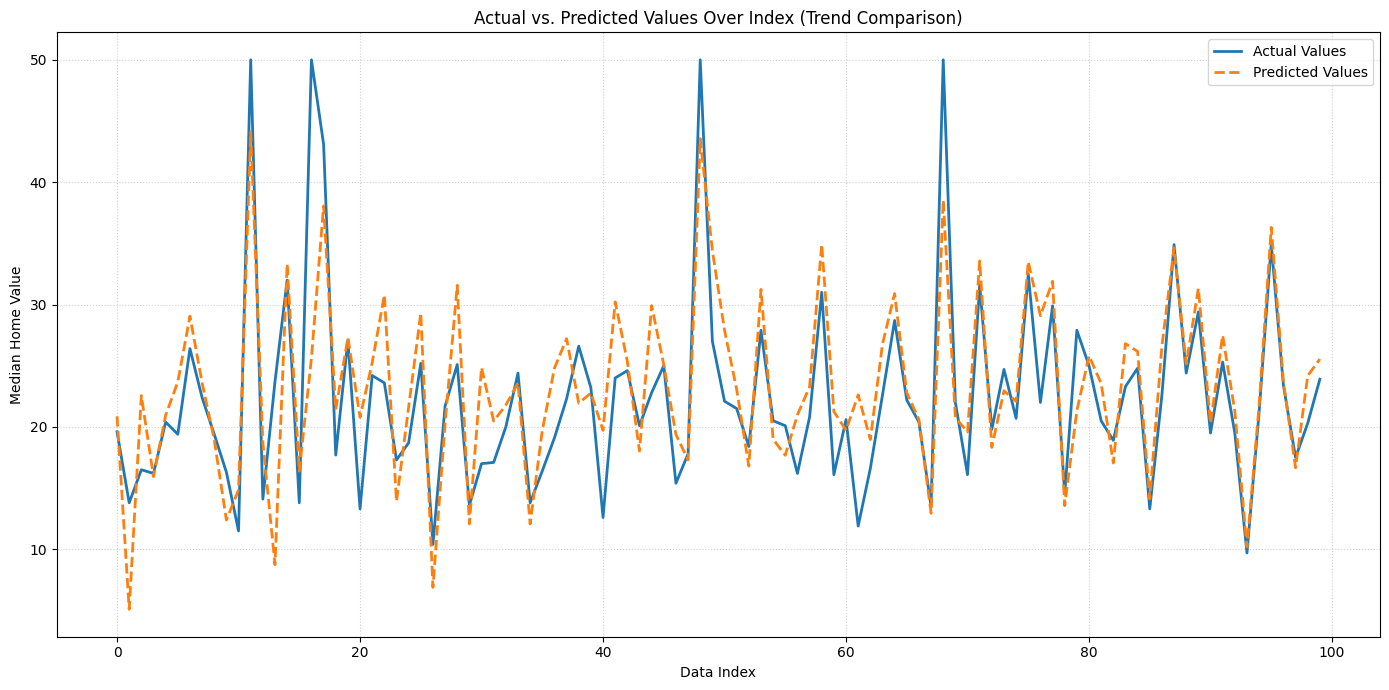

In [39]:
plot_actual_vs_predicted_lines(y_test_split, y_test_pred)

# Save Artefacts

In [40]:
import joblib

In [41]:
model_filename = 'artefacts/final_sgd_reg_model.joblib'
preprocessor_filename = 'artefacts/data_preprocessor.joblib'

In [42]:
joblib.dump(sgd_reg, model_filename)

['artefacts/final_sgd_reg_model.joblib']

In [43]:
joblib.dump(preprocessor, preprocessor_filename)

['artefacts/data_preprocessor.joblib']

# L1 & L2 Regularization

In [46]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np
from sklearn.metrics import r2_score

In [48]:
# --- Lasso Regression ---
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_processed, y_train_split)

# Train pred
y_train_pred_lasso = lasso.predict(X_train_processed)
# Test pred
y_test_pred_lasso = lasso.predict(X_test_processed)

# Train eval
mse_train_lasso = mean_squared_error(y_train_split, y_train_pred_lasso)
lasso_rmse = np.sqrt(mse_train)
lasso_r2 = r2_score(y_train_split, y_train_pred_lasso)

# Test eval
mse_test_lasso = mean_squared_error(y_test_split, y_test_pred_lasso)
lasso_rmse_test = np.sqrt(mse_test)
lasso_r2_test = r2_score(y_test_split, y_test_pred_lasso)

print("Lasso Regression : ")
print("Train RMSE:", lasso_rmse)
print("Train R²:", lasso_r2)
print("Test RMSE:", lasso_rmse_test)
print("Test R²:", lasso_r2_test)
print(f"MSE (TRAIN) (Lasso) : {mse_train_lasso}")
print(f"MSE (TEST) (Lasso): {mse_test_lasso}")
print(f"MSE (TRAIN) (SGD) : {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")


Lasso Regression : 
Train RMSE: 4.6119176207653565
Train R²: 0.7517970999849473
Test RMSE: 4.824254523720516
Test R²: 0.6032900220897899
MSE (TRAIN) (Lasso) : 22.869500610142072
MSE (TEST) (Lasso): 25.593084099473973
MSE (TRAIN) (SGD) : 21.26978414072599
MSE (TEST) (SGD): 23.273431709637862


In [50]:
print(lasso.intercept_)

print(lasso.coef_)

22.739795621626715
[-0.          0.42519719 -0.27871721 -0.48908958  3.15234668 -0.
 -2.2330226  -0.         -1.48482703  1.12972199 -4.70574559  2.82898037
 -0.          1.05697634 -0.12591943 -0.         -1.20109854  0.10963518
  0.17519315  0.        ]


In [ ]:
# --- Ridge Regression ---
ridge = Ridge(alpha=0.1, random_state=42, max_iter=10000)
ridge.fit(X_train_processed, y_train_split)

# Train pred
y_train_pred_ridge = ridge.predict(X_train_processed)
# Test pred
y_test_pred_ridge = ridge.predict(X_test_processed)

# Train eval
mse_train_ridge = mean_squared_error(y_train_split, y_train_pred_ridge)
ridge_rmse = np.sqrt(mse_train)
ridge_r2 = r2_score(y_train_split, y_train_pred_ridge)

# Test eval
mse_test_ridge = mean_squared_error(y_test_split, y_test_pred_ridge)
ridge_rmse_test = np.sqrt(mse_test)
ridge_r2_test = r2_score(y_test_split, y_test_pred_ridge)

print("Ridge Regression : ")
print("Train RMSE:", ridge_rmse)
print("Train R²:", ridge_r2)
print("Test RMSE:", ridge_rmse_test)
print("Test R²:", ridge_r2_test)
print(f"MSE (TRAIN) (ridge) : {mse_train_ridge}")
print(f"MSE (TEST) (ridge): {mse_test_ridge}")
print(f"MSE (TRAIN) (Lasso) : {mse_train_lasso}")
print(f"MSE (TEST) (Lasso): {mse_test_lasso}")
print(f"MSE (TRAIN) (SGD) : {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")


Ridge Regression : 
Train RMSE: 4.6119176207653565
Train R²: 0.7730357035828805
Test RMSE: 4.824254523720516
Test R²: 0.6349524450293651
MSE (TRAIN) (ridge) : 20.912568366755536
MSE (TEST) (ridge): 23.550435569799046
MSE (TRAIN) (Lasso) : 22.869500610142072
MSE (TEST) (Lasso): 25.593084099473973
MSE (TRAIN) (SGD) : 21.26978414072599
MSE (TEST) (SGD): 23.273431709637862


In [51]:
print(ridge.intercept_)

print(ridge.coef_)

19.29533218624162
[-0.41196805  1.06338908  0.25360608 -1.43810962  2.69825872  0.10901886
 -3.13188851 -1.34218954 -1.97890383  1.16115127 -4.68907369  4.06132783
 -0.25621989  4.41022095  1.77503264  1.93777793 -0.6288661   5.66730637
  4.33559311  6.14927017]
